## Environment Setup and Training Configuration

In [56]:
import os
import gc
import zipfile
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

SEED = 42
BATCH_SIZE = 16
N_SPLITS = 5
EPOCHS = 80
REFINE_EPOCHS = 10
TTA_PASSES = 5

AUG_FACTOR = 2
AUG_NOISE_STD = 0.015
AUG_MASK_PROB = 0.03

D_MODEL = 48

def set_all_seeds(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_all_seeds(SEED)

print("Configured:", {
    "N_SPLITS": N_SPLITS,
    "EPOCHS": EPOCHS,
    "REFINE_EPOCHS": REFINE_EPOCHS,
    "TTA_PASSES": TTA_PASSES,
    "AUG_FACTOR": AUG_FACTOR
})

Configured: {'N_SPLITS': 5, 'EPOCHS': 80, 'REFINE_EPOCHS': 10, 'TTA_PASSES': 5, 'AUG_FACTOR': 2}


## Data Extraction, Loading, and Initial Inspection

In [57]:
zip_path = "/content/heart+disease.zip"
extract_path = "/content/heart_data"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

cols = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
]

df = pd.read_csv(
    f"{extract_path}/processed.cleveland.data",
    header=None,
    names=cols,
    na_values="?",
    sep=","
)

print("Shape:", df.shape)
print(df.head())
print("Missing values:\n", df.isna().sum())

Shape: (303, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  num  
0    3.0  0.0   6.0    0  
1    2.0  3.0   3.0    2  
2    2.0  2.0   7.0    1  
3    3.0  0.0   3.0    0  
4    1.0  0.0   3.0    0  
Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


## Target Variable Creation and Class Distribution Analysis

In [58]:
df["target"] = (df["num"] > 0).astype("int32")
df = df.drop(columns=["num"])

print("\nTarget distribution:")
print(df["target"].value_counts(normalize=True).sort_index())


Target distribution:
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


## Feature Engineering and Feature Categorization

In [59]:
def add_features(d):
    out = d.copy()

    out["age_thalach"] = out["age"] * out["thalach"]
    out["chol_trestbps"] = out["chol"] * out["trestbps"]
    out["age_oldpeak"] = out["age"] * (out["oldpeak"] + 1.0)
    out["thalach_oldpeak"] = out["thalach"] * (out["oldpeak"] + 1.0)
    out["bp_thalach_gap"] = out["trestbps"] - out["thalach"]
    out["chol_age_gap"] = out["chol"] - out["age"]

    out["chol_trestbps_ratio"] = out["chol"] / (out["trestbps"] + 1.0)
    out["thalach_age_ratio"] = out["thalach"] / (out["age"] + 1.0)
    out["chol_age_ratio"] = out["chol"] / (out["age"] + 1.0)
    out["bp_age_ratio"] = out["trestbps"] / (out["age"] + 1.0)

    out["risk_score_1"] = out["oldpeak"] * out["exang"]
    out["risk_score_2"] = out["cp"] + out["oldpeak"] + out["exang"]
    out["risk_score_3"] = out["thalach"] - out["oldpeak"] * 10.0
    out["risk_score_4"] = (out["age"] / 50.0) + out["oldpeak"] + out["ca"]
    out["risk_score_5"] = (out["chol"] / 250.0) + (out["trestbps"] / 140.0)

    out["high_chol_flag"] = (out["chol"] > 240).astype("float32")
    out["high_bp_flag"] = (out["trestbps"] > 140).astype("float32")
    out["low_thalach_flag"] = (out["thalach"] < 140).astype("float32")
    out["high_oldpeak_flag"] = (out["oldpeak"] > 1.5).astype("float32")

    out["age_group"] = pd.cut(out["age"], bins=[0, 40, 55, 70, 100], labels=[0, 1, 2, 3]).astype("float32")
    out["bp_chol_interaction"] = out["trestbps"] * out["chol"]
    out["heart_stress_index"] = out["oldpeak"] * out["thalach"]

    return out

df = add_features(df)

cat_cols = ["cp", "restecg", "slope", "ca", "thal"]
num_cols = [c for c in df.columns if c not in cat_cols + ["target"]]
binary_num_cols = ["sex", "fbs", "exang", "high_chol_flag", "high_bp_flag", "low_thalach_flag", "high_oldpeak_flag"]
continuous_num_cols = [c for c in num_cols if c not in binary_num_cols]

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))


Numeric features: 30
Categorical features: 5


## Train-Test Split with Stratification

In [60]:
train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["target"]
)

print("Train+Val:", train_val_df.shape)
print("Test     :", test_df.shape)

Train+Val: (242, 36)
Test     : (61, 36)


## Data Preprocessing, Augmentation, Model Utilities, and Evaluation Functions

In [61]:
def compute_stats(d):
    medians = d[num_cols].median()
    modes = {c: d[c].mode(dropna=True)[0] for c in cat_cols}
    q_low = d[num_cols].quantile(0.01)
    q_high = d[num_cols].quantile(0.99)
    cont_std = d[continuous_num_cols].std().replace(0, 1.0)

    return {
        "medians": medians,
        "modes": modes,
        "q_low": q_low,
        "q_high": q_high,
        "cont_std": cont_std
    }

def clean_frame(d, stats):
    out = d.copy()

    for c in num_cols:
        out[c] = out[c].fillna(stats["medians"][c])

    for c in cat_cols:
        out[c] = out[c].fillna(stats["modes"][c]).round().astype("int32")

    for c in num_cols:
        out[c] = out[c].clip(stats["q_low"][c], stats["q_high"][c])

    out["target"] = out["target"].astype("int32")
    return out

def augment_training_frame(d, stats, factor=2, noise_std=0.015, mask_prob=0.03, seed=42):
    rng = np.random.default_rng(seed)
    base = d.copy().reset_index(drop=True)
    frames = [base]

    cont_idx = [num_cols.index(c) for c in continuous_num_cols]
    stds = stats["cont_std"].values

    for _ in range(factor - 1):
        aug = base.copy()
        x = aug[num_cols].astype("float32").values

        noise = rng.normal(0, stds * noise_std, size=(len(aug), len(cont_idx)))
        x[:, cont_idx] = x[:, cont_idx] + noise

        mask = rng.random((len(aug), len(cont_idx))) < mask_prob
        x[:, cont_idx][mask] = np.nan

        for j, c in enumerate(num_cols):
            aug[c] = x[:, j]

        frames.append(aug)

    return pd.concat(frames, ignore_index=True)

def build_x_dict(d):
    x = {"num_input": d[num_cols].astype("float32").values}
    for c in cat_cols:
        x[c] = d[c].astype(str).values
    return x

def class_weight_from_df(d):
    y = d["target"].values
    n0 = int(np.sum(y == 0))
    n1 = int(np.sum(y == 1))
    total = len(y)
    return {0: total / (2.0 * max(n0, 1)), 1: total / (2.0 * max(n1, 1))}

def build_preprocessors(train_clean):
    normalizer = layers.Normalization(axis=-1, name="num_norm")
    normalizer.adapt(train_clean[num_cols].astype("float32").values)

    lookup_layers = {}
    for c in cat_cols:
        lookup = layers.StringLookup(
            output_mode="int",
            mask_token=None,
            num_oov_indices=1,
            name=f"{c}_lookup"
        )
        lookup.adapt(train_clean[c].astype(str).values)
        lookup_layers[c] = lookup

    return normalizer, lookup_layers

def compile_model(model):
    try:
        opt = tf.keras.optimizers.AdamW(
            learning_rate=2.5e-4,
            weight_decay=1e-5,
            clipnorm=1.0
        )
    except Exception:
        opt = tf.keras.optimizers.Adam(learning_rate=2.5e-4, clipnorm=1.0)

    try:
        loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=1.5, alpha=0.4)
    except Exception:
        loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.02)

    model.compile(
        optimizer=opt,
        loss=loss_fn,
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return model

def set_model_lr(model, lr):
    try:
        model.optimizer.learning_rate.assign(lr)
    except Exception:
        try:
            tf.keras.backend.set_value(model.optimizer.learning_rate, lr)
        except Exception:
            pass

def find_best_threshold(y_true, probs, metric="balanced_accuracy"):
    thresholds = np.linspace(0.05, 0.95, 181)
    best_th, best_score = 0.5, -1.0

    for th in thresholds:
        preds = (probs >= th).astype(int)
        if metric == "f1":
            score = f1_score(y_true, preds, zero_division=0)
        elif metric == "accuracy":
            score = accuracy_score(y_true, preds)
        else:
            tp = np.sum((preds == 1) & (y_true == 1))
            tn = np.sum((preds == 0) & (y_true == 0))
            p = np.sum(y_true == 1)
            n = np.sum(y_true == 0)
            score = 0.5 * ((tp / max(p, 1)) + (tn / max(n, 1)))

        if score > best_score:
            best_score = score
            best_th = th

    return best_th, best_score

def evaluate(y_true, probs, threshold, name="Set"):
    preds = (probs >= threshold).astype(int)

    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)
    auc = roc_auc_score(y_true, probs)
    pr_auc = average_precision_score(y_true, probs)

    print(f"\n===== {name} =====")
    print("Threshold :", round(threshold, 4))
    print("Accuracy  :", round(acc, 4))
    print("Precision :", round(prec, 4))
    print("Recall    :", round(rec, 4))
    print("F1 score  :", round(f1, 4))
    print("ROC AUC   :", round(auc, 4))
    print("PR AUC    :", round(pr_auc, 4))
    print("\nClassification report:\n")
    print(classification_report(y_true, preds, digits=4))

    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "pr_auc": pr_auc,
        "threshold": threshold
    }

def make_callbacks(model_name, fold_id, patience=10):
    return [
        ModelCheckpoint(
            f"{model_name}_fold_{fold_id}.keras",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=max(3, patience // 2),
            min_lr=1e-5,
            verbose=1
        )
    ]

## Model Architecture Components: Transformer Block, Residual Gating, and Attention Pooling

In [62]:
def transformer_block(x, d_model=48, num_heads=4, ff_dim=96, dropout=0.10):
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=max(8, d_model // num_heads),
        dropout=dropout
    )(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    ffn = layers.Dense(ff_dim, activation="gelu")(x)
    ffn = layers.Dropout(dropout)(ffn)
    ffn = layers.Dense(d_model)(ffn)

    x = layers.Add()([x, ffn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

def residual_gate_block(x, width=96, dropout=0.12, l2=1e-4):
    shortcut = x
    x = layers.Dense(width, activation="swish", kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Dense(width, activation="swish", kernel_regularizer=regularizers.l2(l2))(x)
    gate = layers.Dense(width, activation="sigmoid")(x)
    x = layers.Multiply()([x, gate])

    x = layers.Dense(width, kernel_regularizer=regularizers.l2(l2))(x)
    if int(shortcut.shape[-1]) != width:
        shortcut = layers.Dense(width, kernel_regularizer=regularizers.l2(l2))(shortcut)

    x = layers.Add()([shortcut, x])
    x = layers.Activation("swish")(x)
    x = layers.BatchNormalization()(x)
    return x

def attention_pool_1d(x):
    score = layers.Dense(1)(x)
    score = layers.Softmax(axis=1)(score)
    return layers.Multiply()([x, score])

## Model Architectures: FT-Transformer, Gated Residual MLP, CNN-Transformer, and Ensemble Gate

In [63]:
def build_ft_transformer(normalizer, lookup_layers):
    num_input = layers.Input(shape=(len(num_cols),), name="num_input")
    x_num = normalizer(num_input)
    x_num = layers.GaussianNoise(0.02)(x_num)
    num_summary = layers.Dense(32, activation="swish")(x_num)

    x_num_tok = layers.Reshape((len(num_cols), 1))(x_num)
    x_num_tok = layers.Dense(D_MODEL)(x_num_tok)

    cat_inputs, cat_tokens = [], []
    for c in cat_cols:
        inp = layers.Input(shape=(), dtype=tf.string, name=c)
        idx = lookup_layers[c](inp)
        vocab_size = lookup_layers[c].vocabulary_size()
        emb_dim = max(2, min(8, int(np.ceil(np.sqrt(vocab_size + 1)))))
        e = layers.Embedding(vocab_size, emb_dim, name=f"{c}_emb")(idx)
        e = layers.Reshape((1, emb_dim))(e)
        e = layers.Dense(D_MODEL)(e)
        cat_inputs.append(inp)
        cat_tokens.append(e)

    tokens = layers.Concatenate(axis=1)([x_num_tok] + cat_tokens)
    x = layers.LayerNormalization(epsilon=1e-6)(tokens)
    x = transformer_block(x, d_model=D_MODEL, num_heads=4, ff_dim=96, dropout=0.10)
    x = transformer_block(x, d_model=D_MODEL, num_heads=4, ff_dim=96, dropout=0.08)
    x = attention_pool_1d(x)

    pooled = layers.Concatenate()([
        layers.GlobalAveragePooling1D()(x),
        layers.GlobalMaxPooling1D()(x)
    ])

    fused = layers.Concatenate()([pooled, num_summary])
    fused = layers.Dense(96, activation="swish", kernel_regularizer=regularizers.l2(1e-4))(fused)
    fused = layers.Dropout(0.18)(fused)
    fused = layers.Dense(48, activation="swish", kernel_regularizer=regularizers.l2(1e-4))(fused)
    fused = layers.Dropout(0.08)(fused)
    out = layers.Dense(1, activation="sigmoid")(fused)

    model = Model([num_input] + cat_inputs, out, name="ft_transformer")
    return compile_model(model)

def build_gated_residual_mlp(normalizer, lookup_layers):
    num_input = layers.Input(shape=(len(num_cols),), name="num_input")
    x_num = normalizer(num_input)
    x_num = layers.GaussianNoise(0.02)(x_num)
    num_summary = layers.Dense(32, activation="swish")(x_num)

    cat_inputs, parts = [], [x_num, num_summary]
    for c in cat_cols:
        inp = layers.Input(shape=(), dtype=tf.string, name=c)
        idx = lookup_layers[c](inp)
        vocab_size = lookup_layers[c].vocabulary_size()
        emb_dim = max(2, min(8, int(np.ceil(np.sqrt(vocab_size + 1)))))
        e = layers.Embedding(vocab_size, emb_dim, name=f"{c}_emb")(idx)
        e = layers.Reshape((emb_dim,))(e)
        cat_inputs.append(inp)
        parts.append(e)

    x = layers.Concatenate()(parts)
    x = residual_gate_block(x, width=128, dropout=0.12)
    x = residual_gate_block(x, width=128, dropout=0.10)
    x = residual_gate_block(x, width=96, dropout=0.10)
    x = layers.Dense(64, activation="swish")(x)
    x = layers.Dropout(0.10)(x)
    x = layers.Dense(32, activation="swish")(x)
    x = layers.Dropout(0.06)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model([num_input] + cat_inputs, out, name="gated_residual_mlp")
    return compile_model(model)

def build_cnn_transformer(normalizer, lookup_layers):
    num_input = layers.Input(shape=(len(num_cols),), name="num_input")
    x_num = normalizer(num_input)
    x_num = layers.GaussianNoise(0.02)(x_num)
    num_summary = layers.Dense(32, activation="swish")(x_num)

    x_num_tok = layers.Reshape((len(num_cols), 1))(x_num)
    x_num_tok = layers.Dense(D_MODEL)(x_num_tok)

    cat_inputs, cat_tokens = [], []
    for c in cat_cols:
        inp = layers.Input(shape=(), dtype=tf.string, name=c)
        idx = lookup_layers[c](inp)
        vocab_size = lookup_layers[c].vocabulary_size()
        emb_dim = max(2, min(8, int(np.ceil(np.sqrt(vocab_size + 1)))))
        e = layers.Embedding(vocab_size, emb_dim, name=f"{c}_emb")(idx)
        e = layers.Reshape((1, emb_dim))(e)
        e = layers.Dense(D_MODEL)(e)
        cat_inputs.append(inp)
        cat_tokens.append(e)

    tokens = layers.Concatenate(axis=1)([x_num_tok] + cat_tokens)

    x = layers.Conv1D(64, 1, padding="same", activation="swish")(tokens)
    x = layers.Dropout(0.10)(x)
    x = layers.Conv1D(64, 3, padding="same", activation="swish")(x)
    x = layers.Dropout(0.10)(x)
    x = layers.Conv1D(32, 1, padding="same", activation="swish")(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = transformer_block(x, d_model=32, num_heads=4, ff_dim=64, dropout=0.08)
    x = attention_pool_1d(x)

    pooled = layers.Concatenate()([
        layers.GlobalAveragePooling1D()(x),
        layers.GlobalMaxPooling1D()(x)
    ])

    fused = layers.Concatenate()([pooled, num_summary])
    fused = layers.Dense(96, activation="swish")(fused)
    fused = layers.Dropout(0.12)(fused)
    fused = layers.Dense(48, activation="swish")(fused)
    fused = layers.Dropout(0.06)(fused)
    out = layers.Dense(1, activation="sigmoid")(fused)

    model = Model([num_input] + cat_inputs, out, name="cnn_transformer")
    return compile_model(model)

def build_gate():
    inp = layers.Input(shape=(3,), name="gate_input")
    x = layers.Dense(12, activation="swish")(inp)
    x = layers.Dropout(0.08)(x)
    x = layers.Dense(6, activation="swish")(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inp, out, name="deep_gate")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

## Test-Time Augmentation (TTA) Prediction Function

In [64]:
def tta_predict(model, d_clean, stats, n_passes=5, seed=123):
    rng = np.random.default_rng(seed)
    base = d_clean.copy().reset_index(drop=True)
    preds = []

    cont_idx = [num_cols.index(c) for c in continuous_num_cols]
    stds = stats["cont_std"].values

    for i in range(n_passes):
        temp = base.copy()
        x = temp[num_cols].astype("float32").values
        noise = rng.normal(0, stds * 0.008, size=(len(temp), len(cont_idx)))
        x[:, cont_idx] = x[:, cont_idx] + noise

        for j, c in enumerate(num_cols):
            temp[c] = x[:, j]

        temp = clean_frame(temp, stats)
        probs = model.predict(build_x_dict(temp), batch_size=BATCH_SIZE, verbose=0).ravel()
        preds.append(probs)

    return np.mean(np.vstack(preds), axis=0)

## Fold-wise Model Training with Augmentation, Refinement, and TTA Evaluation

In [65]:
def train_one_fold_model(model_builder, model_name, tr_clean, va_clean, te_clean, fold_id):
    print("\n--- FOLD STATS ---")
    print("Train size:", len(tr_clean), "| Val size:", len(va_clean), "| Test size:", len(te_clean))
    print("Train positive rate:", round(float(tr_clean["target"].mean()), 4))
    print("Val positive rate  :", round(float(va_clean["target"].mean()), 4))

    stats = compute_stats(tr_clean)

    # fold-safe augmentation
    tr_aug = augment_training_frame(
        tr_clean,
        stats=stats,
        factor=AUG_FACTOR,
        noise_std=AUG_NOISE_STD,
        mask_prob=AUG_MASK_PROB,
        seed=SEED + fold_id
    )
    tr_aug = clean_frame(tr_aug, stats)

    print("\n--- AUGMENTATION ---")
    print("Original train:", len(tr_clean))
    print("Augmented train:", len(tr_aug))

    normalizer, lookup_layers = build_preprocessors(tr_clean)
    model = model_builder(normalizer, lookup_layers)

    x_train = build_x_dict(tr_aug)
    y_train = tr_aug["target"].values.astype("int32")
    x_val = build_x_dict(va_clean)
    y_val = va_clean["target"].values.astype("int32")
    x_test = build_x_dict(te_clean)

    cw = class_weight_from_df(tr_aug)

    print("\n--- INITIAL TRAINING:", model_name, "---")
    model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        class_weight=cw,
        shuffle=True,
        verbose=1,
        callbacks=make_callbacks(model_name, fold_id, patience=10)
    )

    print("\n--- HARD-EXAMPLE REFINEMENT:", model_name, "---")
    train_probs = model.predict(x_train, batch_size=BATCH_SIZE, verbose=0).ravel()
    hardness = np.abs(y_train - train_probs)
    sample_weight = 1.0 + 2.5 * hardness
    sample_weight = np.clip(sample_weight, 1.0, 3.0)

    set_model_lr(model, 5e-5)

    model.fit(
        x_train, y_train,
        sample_weight=sample_weight,
        validation_data=(x_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=REFINE_EPOCHS,
        shuffle=True,
        verbose=1,
        callbacks=make_callbacks(model_name + "_refine", fold_id, patience=4)
    )

    val_probs = tta_predict(model, va_clean, stats=stats, n_passes=3, seed=1000 + fold_id)
    test_probs = tta_predict(model, te_clean, stats=stats, n_passes=TTA_PASSES, seed=2000 + fold_id)

    return model, val_probs, test_probs, stats

## Cross-Validation Training Loop with Out-of-Fold Predictions and Fold Diagnostics

In [66]:
def train_cv_model(model_builder, model_name, full_df, test_df):
    full_df = full_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    y_full = full_df["target"].values.astype("int32")

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    oof_probs = np.zeros(len(full_df), dtype=np.float32)
    test_fold_probs = []
    fold_metrics = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(full_df, y_full), start=1):
        print(f"\n========== {model_name.upper()} | FOLD {fold}/{N_SPLITS} ==========")

        tf.keras.backend.clear_session()
        gc.collect()
        set_all_seeds(SEED + fold)

        tr_raw = full_df.iloc[tr_idx].reset_index(drop=True)
        va_raw = full_df.iloc[va_idx].reset_index(drop=True)

        stats = compute_stats(tr_raw)
        tr_clean = clean_frame(tr_raw, stats)
        va_clean = clean_frame(va_raw, stats)
        te_clean = clean_frame(test_df, stats)

        model, va_probs, te_probs, _ = train_one_fold_model(
            model_builder, model_name, tr_clean, va_clean, te_clean, fold
        )

        oof_probs[va_idx] = va_probs
        test_fold_probs.append(te_probs)

        y_va = va_clean["target"].values
        pred_05 = (va_probs >= 0.5).astype(int)

        auc = roc_auc_score(y_va, va_probs)
        pr_auc = average_precision_score(y_va, va_probs)
        acc = accuracy_score(y_va, pred_05)
        f1 = f1_score(y_va, pred_05, zero_division=0)

        print("\n--- FOLD DIAGNOSTICS ---")
        print("Val AUC            :", round(auc, 4))
        print("Val PR AUC         :", round(pr_auc, 4))
        print("Val ACC@0.5        :", round(acc, 4))
        print("Val F1@0.5         :", round(f1, 4))
        print("Pred positive rate :", round(float(pred_05.mean()), 4))
        print("True positive rate :", round(float(y_va.mean()), 4))
        print("Confusion matrix @0.5:\n", confusion_matrix(y_va, pred_05))
        print("\nClassification report @0.5:\n")
        print(classification_report(y_va, pred_05, digits=4))

        fold_metrics.append({
            "fold": fold,
            "val_auc": auc,
            "val_pr_auc": pr_auc,
            "val_acc_05": acc,
            "val_f1_05": f1,
            "pred_rate_05": float(pred_05.mean())
        })

        del model
        gc.collect()

    test_probs = np.mean(np.vstack(test_fold_probs), axis=0)
    return oof_probs, test_probs, pd.DataFrame(fold_metrics)

## Training Multiple Models using Cross-Validation

In [67]:
train_full = train_val_df.copy().reset_index(drop=True)
test_full = test_df.copy().reset_index(drop=True)

ft_oof, ft_test, ft_metrics = train_cv_model(build_ft_transformer, "ft_transformer", train_full, test_full)
mlp_oof, mlp_test, mlp_metrics = train_cv_model(build_gated_residual_mlp, "gated_mlp", train_full, test_full)
cnn_oof, cnn_test, cnn_metrics = train_cv_model(build_cnn_transformer, "cnn_transformer", train_full, test_full)



========== FT_TRANSFORMER | FOLD 1/5 ==========

--- FOLD STATS ---
Train size: 193 | Val size: 49 | Test size: 61
Train positive rate: 0.456
Val positive rate  : 0.4694

--- AUGMENTATION ---
Original train: 193
Augmented train: 386

--- INITIAL TRAINING: ft_transformer ---
Epoch 1/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5919 - auc: 0.6400 - loss: 0.2515 - pr_auc: 0.6267 - precision: 0.5460 - recall: 0.8042
Epoch 1: val_auc improved from None to 0.85953, saving model to ft_transformer_fold_1.keras

Epoch 1: finished saving model to ft_transformer_fold_1.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - accuracy: 0.6477 - auc: 0.7052 - loss: 0.2417 - pr_auc: 0.6721 - precision: 0.5926 - recall: 0.7273 - val_accuracy: 0.7551 - val_auc: 0.8595 - val_loss: 0.2059 - val_pr_auc: 0.7718 - val_precision: 0.7619 - val_recall: 0.6957 - learning_rate: 2.5000e-04
Epoch 2/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7529 - auc: 0.8232 - loss: 0.2097 - pr_auc: 0.8101 - 

## Model Evaluation and Weighted Ensemble Construction Based on AUC

In [68]:
y_train = train_full["target"].values.astype(int)

ft_auc = roc_auc_score(y_train, ft_oof)
mlp_auc = roc_auc_score(y_train, mlp_oof)
cnn_auc = roc_auc_score(y_train, cnn_oof)

auc_arr = np.array([ft_auc, mlp_auc, cnn_auc], dtype=np.float32)
weights = auc_arr / auc_arr.sum()

print(f"FT-Transformer AUC : {ft_auc:.4f}")
print(f"Gated MLP AUC      : {mlp_auc:.4f}")
print(f"CNN-Transformer AUC: {cnn_auc:.4f}")
print("Weights:", weights)

ensemble_oof = weights[0] * ft_oof + weights[1] * mlp_oof + weights[2] * cnn_oof
ensemble_test = weights[0] * ft_test + weights[1] * mlp_test + weights[2] * cnn_test


FT-Transformer AUC : 0.8552
Gated MLP AUC      : 0.7907
CNN-Transformer AUC: 0.8817
Weights: [0.33833975 0.31281802 0.34884226]


## Meta-Learner (Gating Model) Training and Final Ensemble Blending

In [69]:
gate_x = np.column_stack([ft_oof, mlp_oof, cnn_oof]).astype("float32")
gate_test_x = np.column_stack([ft_test, mlp_test, cnn_test]).astype("float32")

gate_model = build_gate()
gate_model.fit(
    gate_x,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=16,
    class_weight=class_weight_from_df(train_full),
    verbose=1,
    callbacks=[
        EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=4, min_lr=1e-5, verbose=1)
    ]
)

gate_oof = gate_model.predict(gate_x, verbose=0).ravel()
gate_test = gate_model.predict(gate_test_x, verbose=0).ravel()

final_oof = 0.55 * ensemble_oof + 0.45 * gate_oof
final_test = 0.55 * ensemble_test + 0.45 * gate_test


Epoch 1/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5699 - auc: 0.6761 - loss: 0.6813 - val_accuracy: 0.5510 - val_auc: 0.5758 - val_loss: 0.6880 - learning_rate: 0.0010
Epoch 2/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5699 - auc: 0.7018 - loss: 0.6793 - val_accuracy: 0.5918 - val_auc: 0.6027 - val_loss: 0.6849 - learning_rate: 0.0010
Epoch 3/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6010 - auc: 0.7397 - loss: 0.6763 - val_accuracy: 0.5918 - val_auc: 0.6406 - val_loss: 0.6822 - learning_rate: 0.0010
Epoch 4/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5492 - auc: 0.7585 - loss: 0.6745 - val_accuracy: 0.5918 - val_auc: 0.6709 - val_loss: 0.6796 - learning_rate: 0.0010
Epoch 5/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5389 - auc: 0.7539 - loss: 0.6752 - val_accuracy: 0.6122 - val_auc: 0.6835 - val_loss: 0.6775 - learning_rate: 0.0010
Epoch 6/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5596 - auc: 0.7572 - lo

## Optimal Threshold Selection Based on Evaluation Metrics

In [70]:
th_f1, sc_f1 = find_best_threshold(y_train, final_oof, metric="f1")
th_acc, sc_acc = find_best_threshold(y_train, final_oof, metric="accuracy")
th_bal, sc_bal = find_best_threshold(y_train, final_oof, metric="balanced_accuracy")

print(f"Best threshold by F1               : {th_f1:.4f} | {sc_f1:.4f}")
print(f"Best threshold by accuracy         : {th_acc:.4f} | {sc_acc:.4f}")
print(f"Best threshold by balanced accuracy: {th_bal:.4f} | {sc_bal:.4f}")

final_threshold = th_bal


Best threshold by F1               : 0.4450 | 0.7639
Best threshold by accuracy         : 0.5100 | 0.7934
Best threshold by balanced accuracy: 0.5100 | 0.7878


## Final Model Evaluation and Performance Summary on Test Set


===== TEST =====
Threshold : 0.51
Accuracy  : 0.918
Precision : 0.8966
Recall    : 0.9286
F1 score  : 0.9123
ROC AUC   : 0.9751
PR AUC    : 0.9714

Classification report:

              precision    recall  f1-score   support

           0     0.9375    0.9091    0.9231        33
           1     0.8966    0.9286    0.9123        28

    accuracy                         0.9180        61
   macro avg     0.9170    0.9188    0.9177        61
weighted avg     0.9187    0.9180    0.9181        61



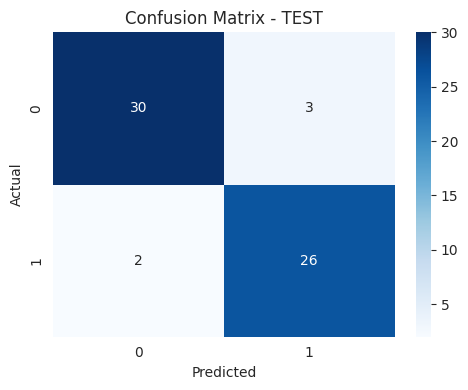


================ FINAL SUMMARY ================
Accuracy : 0.918
ROC AUC  : 0.9751
PR AUC   : 0.9714
F1       : 0.9123
Threshold: 0.51


In [71]:
results = evaluate(
    test_full["target"].values.astype(int),
    final_test,
    final_threshold,
    name="TEST"
)

print("\n================ FINAL SUMMARY ================")
print("Accuracy :", round(results["accuracy"], 4))
print("ROC AUC  :", round(results["auc"], 4))
print("PR AUC   :", round(results["pr_auc"], 4))
print("F1       :", round(results["f1"], 4))
print("Threshold:", round(results["threshold"], 4))

## Saving Predictions and Cross-Validation Metrics to Files

In [72]:
pred_df = pd.DataFrame({
    "true_label": test_full["target"].values.astype(int),
    "pred_prob": final_test,
    "pred_label": (final_test >= final_threshold).astype(int)
})
pred_df.to_csv("heart_test_predictions.csv", index=False)

metrics_df = pd.concat([
    ft_metrics.assign(model="ft_transformer"),
    mlp_metrics.assign(model="gated_mlp"),
    cnn_metrics.assign(model="cnn_transformer"),
], ignore_index=True)
metrics_df.to_csv("heart_fold_metrics.csv", index=False)

print("Saved: heart_test_predictions.csv")
print("Saved: heart_fold_metrics.csv")


Saved: heart_test_predictions.csv
Saved: heart_fold_metrics.csv


## Visualization of Prediction Distribution and Confusion Matrix

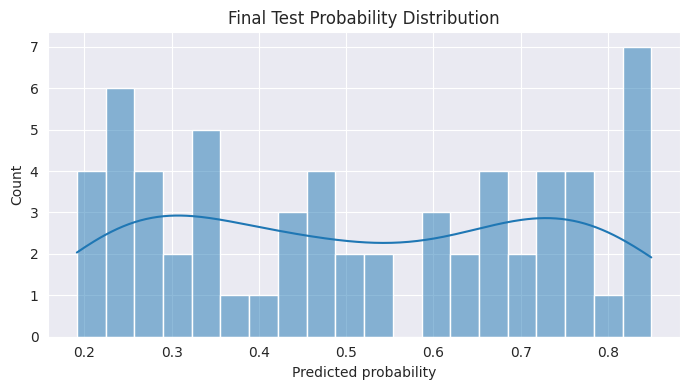

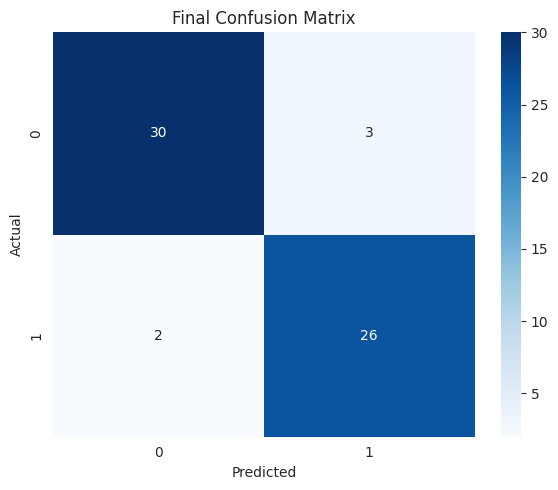

In [74]:
plt.figure(figsize=(7, 4))
sns.histplot(final_test, bins=20, kde=True)
plt.title("Final Test Probability Distribution")
plt.xlabel("Predicted probability")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
cm = confusion_matrix(test_full["target"].values.astype(int), (final_test >= final_threshold).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
